In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Load Data
df = pd.read_csv('process_data.csv')
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,total_spend,order_velocity,order_velociy
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,50,0.20,800,808.64,0.156863,NaN
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.30,37,0.34,907,903.90,0.263158,NaN
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,50.95,65,0.05,850,499.68,0.090909,NaN
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.90,93,0.19,2228,989.10,0.095745,NaN
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.30,79,0.15,492,4310.08,0.200000,NaN


In [36]:
print("Shape:", df.shape)
print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Target Class Distribution ---")
print(df['is_fraudulent'].value_counts(normalize=True) * 100)


Shape: (5000, 16)

--- Missing Values ---
customer_id             0
age                     0
gender                  0
country                 0
avg_order_value         0
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
email_open_rate         0
loyalty_score           0
churn_risk              0
customer_tenure_days    0
total_spend             0
order_velocity          0
order_velociy           0
dtype: int64

--- Target Class Distribution ---
is_fraudulent
0    97.42
1     2.58
Name: proportion, dtype: float64


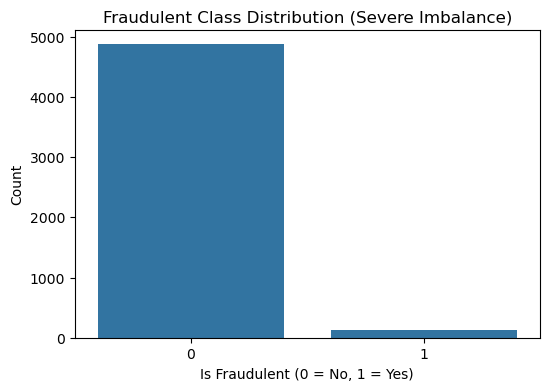

In [37]:
# target ka graph bhi bana kr dekh lete hain
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraudulent', data=df)
plt.title('Fraudulent Class Distribution (Severe Imbalance)')
plt.xlabel('Is Fraudulent (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()